In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_excel("D:\OIBSIP\DataAnalytics-L1-CustomerSegmentation\data\Online Retail.xlsx")

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\surab\AppData\Local\Temp\ipykernel_4108\3274655767.py:1: SyntaxWarning: invalid escape sequence '\O'
  df = pd.read_excel("D:\OIBSIP\DataAnalytics-L1-CustomerSegmentation\data\Online Retail.xlsx")


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df.dropna(subset=["CustomerID"])

In [11]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [12]:
duplicates_before = df.duplicated().sum()

print("Duplicate rows:", duplicates_before)

Duplicate rows: 5225


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df[df["Quantity"] > 0]

In [16]:
df = df[df["UnitPrice"] > 0]

In [17]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [19]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [20]:
df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [22]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [23]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [24]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [26]:
print("Average Recency:", rfm["Recency"].mean())
print("Average Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())

Average Recency: 92.53642231443061
Average Frequency: 4.272014753342554
Average Monetary Value: 2048.688080682342


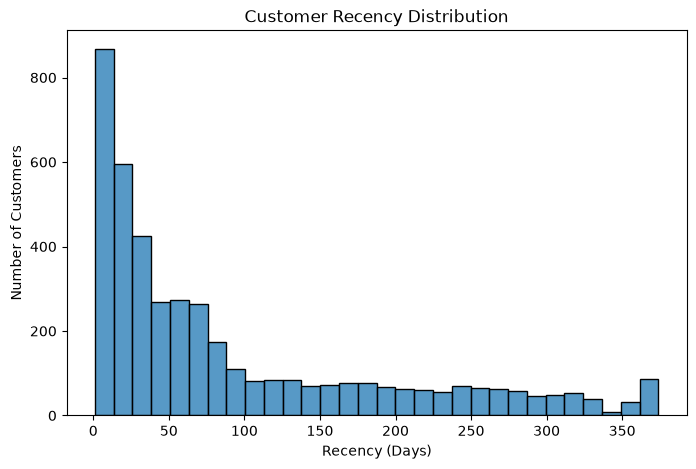

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["Recency"], bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

Observation

The Recency distribution shows how recently customers made their purchases. Customers with lower recency values are more recently active, while customers with higher values may require re-engagement campaigns.

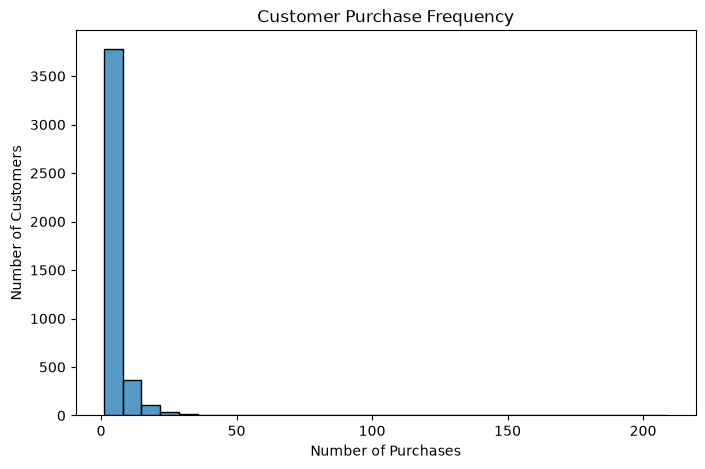

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["Frequency"], bins=30)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

Observation

Most customers make a relatively small number of purchases, while a smaller group of customers purchases more frequently. These frequent customers may represent an important loyalty segment.

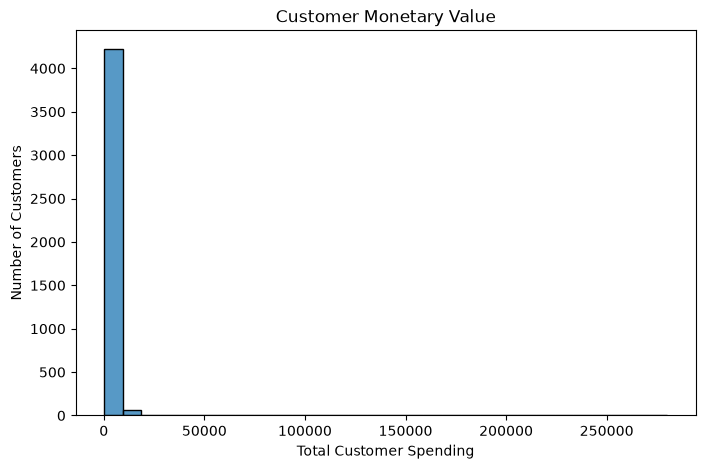

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["Monetary"], bins=30)

plt.title("Customer Monetary Value")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")

plt.show()

Observation

The monetary distribution shows differences in customer spending. A smaller group of customers may contribute a disproportionately large share of total revenue, making them potential high-value customers.

In [30]:
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

In [31]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

In [32]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [33]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

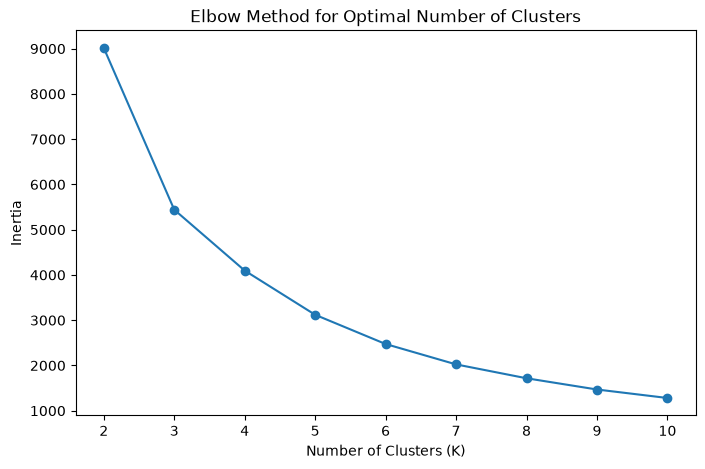

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [42]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

In [43]:
cluster_profile = rfm.groupby("Cluster")[features].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [44]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

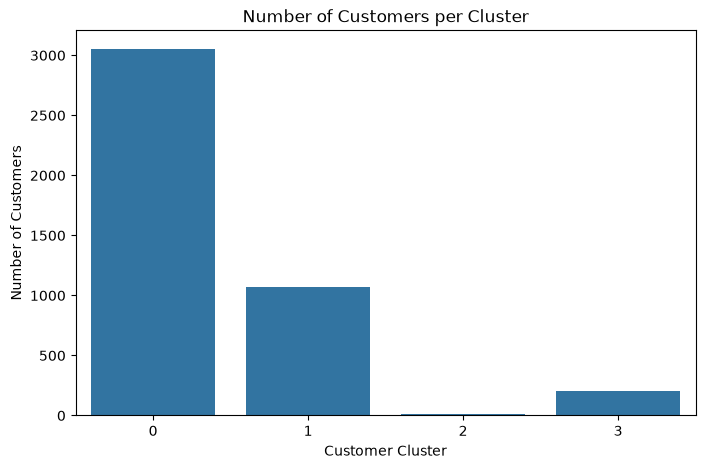

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

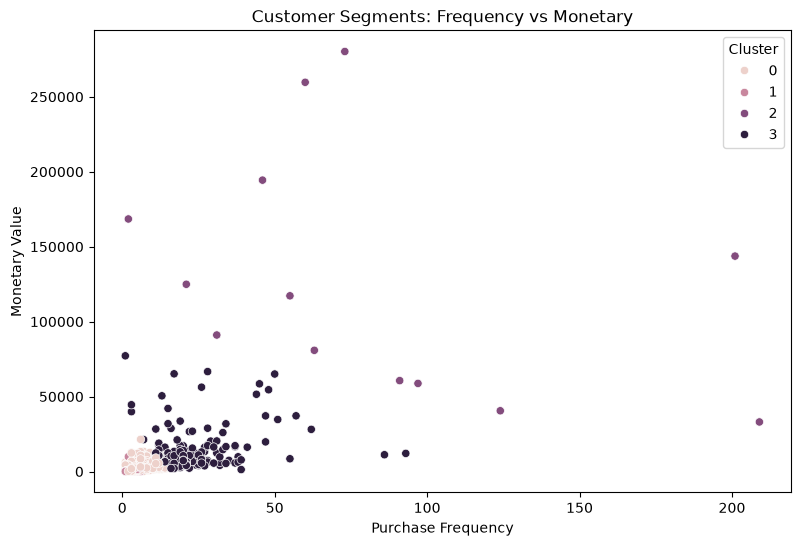

In [46]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

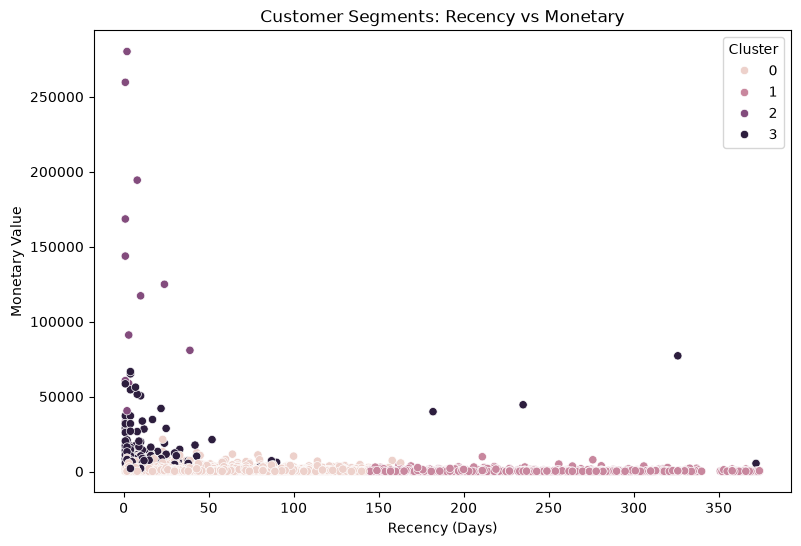

In [47]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.show()

In [48]:
cluster_profile

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


# Marketing Recommendations

## High-Value Customers
Provide VIP benefits, exclusive offers, loyalty rewards, and early access to new products.

## Loyal Customers
Use loyalty programs, personalized recommendations, and repeat-purchase incentives.

## At-Risk Customers
Use re-engagement campaigns, personalized discounts, and reminder emails.

## Low-Value Customers
Use targeted introductory offers and low-cost campaigns to encourage additional purchases.

In [49]:
rfm.to_csv("../data/customer_segments.csv")

In [50]:
plt.savefig("../images/elbow_method.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [51]:
plt.savefig("../images/cluster_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [52]:
plt.savefig("../images/frequency_vs_monetary.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [53]:
plt.savefig("../images/recency_vs_monetary.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>